# Libs

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

DIR_DATA = os.getcwd() + '/data/'

# Load Datasets

Carregando dados e visualizando estrutura dos dataframes

In [2]:
df_circuits = pd.read_csv(DIR_DATA + 'circuits.csv', sep=',', na_values='\\N')
print("Circuits Dataset")
print(f"Columns: {list(df_circuits.columns)}")
print(f"Shape: {df_circuits.shape}")
df_circuits.head()

Circuits Dataset
Columns: ['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng', 'alt', 'url']
Shape: (77, 9)


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


In [3]:
df_constructors_results = pd.read_csv(DIR_DATA + 'constructor_results.csv', sep=',', na_values='\\N')
print("Constructors Results Dataset")
print(f"Columns: {list(df_constructors_results.columns)}")
print(f"Shape: {df_constructors_results.shape}")
df_constructors_results.head()

Constructors Results Dataset
Columns: ['constructorResultsId', 'raceId', 'constructorId', 'points', 'status']
Shape: (12625, 5)


,constructorResultsId,raceId,constructorId,points,status
0,1,18,1,14.0,NaN
1,2,18,2,8.0,NaN
2,3,18,3,9.0,NaN
3,4,18,4,5.0,NaN
4,5,18,5,2.0,NaN


In [4]:
df_constructors_standings = pd.read_csv(DIR_DATA + 'constructor_standings.csv', sep=',', na_values='\\N')
print("Constructors Standings Dataset")
print(f"Columns : {list(df_constructors_standings.columns)}")
print(f"Shape: {df_constructors_standings.shape}")
df_constructors_standings.head()

Constructors Standings Dataset
Columns : ['constructorStandingsId', 'raceId', 'constructorId', 'points', 'position', 'positionText', 'wins']
Shape: (13391, 7)


,constructorStandingsId,raceId,constructorId,points,position,positionText,wins
0,1,18,1,14.0,1,1,1
1,2,18,2,8.0,3,3,0
2,3,18,3,9.0,2,2,0
3,4,18,4,5.0,4,4,0
4,5,18,5,2.0,5,5,0


In [5]:
df_driver_standings = pd.read_csv(DIR_DATA + 'driver_standings.csv', sep=',', na_values='\\N')
print("Drivers Standings Dataset")
print(f"Columns : {list(df_driver_standings.columns)}")
print(f"Shape: {df_driver_standings.shape}")
df_driver_standings.head()

Drivers Standings Dataset
Columns : ['driverStandingsId', 'raceId', 'driverId', 'points', 'position', 'positionText', 'wins']
Shape: (34863, 7)


,driverStandingsId,raceId,driverId,points,position,positionText,wins
0,1,18,1,10.0,1,1,1
1,2,18,2,8.0,2,2,0
2,3,18,3,6.0,3,3,0
3,4,18,4,5.0,4,4,0
4,5,18,5,4.0,5,5,0


In [6]:
df_drivers = pd.read_csv(DIR_DATA + 'drivers.csv', sep=',', na_values='\\N')
print("Drivers Dataset")
print(f"Columns : {list(df_drivers.columns)}")
print(f"Shape: {df_drivers.shape}")
df_drivers.head()

Drivers Dataset
Columns : ['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob', 'nationality', 'url']
Shape: (861, 9)


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [7]:
df_lap_times = pd.read_csv(DIR_DATA + 'lap_times.csv', sep=',', na_values='\\N')
print("Lap Times Dataset")
print(f"Columns : {list(df_lap_times.columns)}")
print(f"Shape: {df_lap_times.shape}")
df_lap_times.head()

Lap Times Dataset
Columns : ['raceId', 'driverId', 'lap', 'position', 'time', 'milliseconds']
Shape: (589081, 6)


,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


In [8]:
df_pitstops = pd.read_csv(DIR_DATA + 'pit_stops.csv', sep=',', na_values='\\N')
print("PitStops Dataset")
print(f"Columns : {list(df_pitstops.columns)}")
print(f"Shape: {df_pitstops.shape}")
df_pitstops.head()

PitStops Dataset
Columns : ['raceId', 'driverId', 'stop', 'lap', 'time', 'duration', 'milliseconds']
Shape: (11371, 7)


,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842


In [9]:
df_qualifying = pd.read_csv(DIR_DATA + 'qualifying.csv', sep=',', na_values='\\N')
print("Qualifying Dataset")
print(f"Columns : {list(df_qualifying.columns)}")
print(f"Shape: {df_qualifying.shape}")
df_qualifying.head()

Qualifying Dataset
Columns : ['qualifyId', 'raceId', 'driverId', 'constructorId', 'number', 'position', 'q1', 'q2', 'q3']
Shape: (10494, 9)


,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


In [10]:
df_races = pd.read_csv(DIR_DATA + 'races.csv', sep=',', na_values='\\N')
print("Races Dataset")
print(f"Columns : {list(df_races.columns)}")
print(f"Shape: {df_races.shape}")
df_races.head()

Races Dataset
Columns : ['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']
Shape: (1125, 18)


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_results = pd.read_csv(DIR_DATA + 'results.csv', sep=',', na_values='\\N')
print("Results Dataset")
print(f"Columns : {list(df_results.columns)}")
print(f"Shape: {df_results.shape}")
df_results.head()

Results Dataset
Columns : ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']
Shape: (26759, 18)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7.0,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
3,4,18,4,4,5.0,11,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
4,5,18,5,1,23.0,3,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


In [12]:
df_seasons = pd.read_csv(DIR_DATA + 'seasons.csv', sep=',', na_values='\\N')
print("Seasons Dataset")
print(f"Columns : {list(df_seasons.columns)}")
print(f"Shape: {df_seasons.shape}")
df_seasons.head()

Seasons Dataset
Columns : ['year', 'url']
Shape: (75, 2)


,year,url
0,2009,http://en.wikipedia.org/wiki/2009_Formula_One_...
1,2008,http://en.wikipedia.org/wiki/2008_Formula_One_...
2,2007,http://en.wikipedia.org/wiki/2007_Formula_One_...
3,2006,http://en.wikipedia.org/wiki/2006_Formula_One_...
4,2005,http://en.wikipedia.org/wiki/2005_Formula_One_...


In [13]:
df_sprint_results = pd.read_csv(DIR_DATA + 'sprint_results.csv', sep=',', na_values='\\N')
print("Sprints Result Dataset")
print(f"Columns : {list(df_sprint_results.columns)}")
print(f"Shape: {df_sprint_results.shape}")
df_sprint_results.head()

Sprints Result Dataset
Columns : ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'fastestLapTime', 'statusId']
Shape: (360, 16)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId
0,1,1061,830,9,33,2,1.0,1,1,3,17,25:38.426,1538426.0,14.0,1:30.013,1
1,2,1061,1,131,44,1,2.0,2,2,2,17,+1.430,1539856.0,17.0,1:29.937,1
2,3,1061,822,131,77,3,3.0,3,3,1,17,+7.502,1545928.0,17.0,1:29.958,1
3,4,1061,844,6,16,4,4.0,4,4,0,17,+11.278,1549704.0,16.0,1:30.163,1
4,5,1061,846,1,4,6,5.0,5,5,0,17,+24.111,1562537.0,16.0,1:30.566,1


In [14]:
df_status = pd.read_csv(DIR_DATA + 'status.csv', sep=',', na_values='\\N')
print("Status Dataset")
print(f"Columns : {list(df_status.columns)}")
print(f"Shape: {df_status.shape}")
df_status.head()

Status Dataset
Columns : ['statusId', 'status']
Shape: (139, 2)


,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


In [15]:
df_constructors = pd.read_csv(DIR_DATA + 'constructors.csv', sep=',', na_values='\\N')
print("Constructors Dataset")
print(f"Columns : {list(df_constructors.columns)}")
print(f"Shape: {df_constructors.shape}")
df_constructors.head()

Constructors Dataset
Columns : ['constructorId', 'constructorRef', 'name', 'nationality', 'url']
Shape: (212, 5)


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


# Merge datasets

In [17]:
# Juntando Resultados com Corridas (para pegar ano e circuito)
df = df_results.merge(df_races[['raceId', 'year', 'name', 'date', 'circuitId']], on='raceId', how='left')

# Juntando com Pilotos (nome, nacionalidade)
df = df.merge(df_drivers[['driverId', 'driverRef', 'nationality', 'dob']], on='driverId', how='left')

# Juntando com Construtores (equipes)
df = df.merge(df_constructors[['constructorId', 'constructorRef', 'nationality']], on='constructorId', how='left', suffixes=('_driver', '_team'))

# Juntando com Status (causa do fim da corrida)
df = df.merge(df_status[['statusId', 'status']], on='statusId', how='left')

# Juntando com Circuitos (Latitude, Longitude, Altitude)
# Renomeando 'name' para 'circuit_name' para não conflitar com o nome da corrida
df = df.merge(df_circuits[['circuitId', 'name', 'location', 'country', 'lat', 'lng', 'alt']], on='circuitId', how='left', suffixes=('', '_circuit'))
df.rename(columns={'name_circuit': 'circuit_name'}, inplace=True)

# Juntando com Qualificação (Tempos de Q1, Q2, Q3)
# Trazendo apenas os tempos, porque 'position' (grid) já se tem em results
df = df.merge(df_qualifying[['raceId', 'driverId', 'q1', 'q2', 'q3']], on=['raceId', 'driverId'], how='left')

# Juntando com Standings (Pontuação do campeonato NAQUELA corrida)
# Renomeando para evitar conflito com os pontos da corrida e posição de chegada
df = df.merge(df_driver_standings[['raceId', 'driverId', 'points', 'position', 'wins']], on=['raceId', 'driverId'], how='left', suffixes=('', '_season'))
df.rename(columns={'points_season': 'driver_points_season', 'position': 'driver_rank_season', 'wins': 'driver_wins_season'}, inplace=True)

# Limpeza Rápida
# Convertendo posição para numérico (substituindo o que não for numérico por NaN)
df['positionOrder'] = pd.to_numeric(df['positionOrder'], errors='coerce')
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')
df['points'] = pd.to_numeric(df['points'], errors='coerce')

print(f"Dataset consolidado, Shape: {df.shape}")
df.head()

Dataset consolidado, Shape: (26759, 40)


,resultId,raceId,driverId,constructorId,number,grid,driver_rank_season,positionText,positionOrder,points,...,country,lat,lng,alt,q1,q2,q3,driver_points_season,position_season,driver_wins_season
0,1,18,1,1,22.0,1,1.0,1,1,10.0,...,Australia,-37.8497,144.968,10,1:26.572,1:25.187,1:26.714,10.0,1.0,1.0
1,2,18,2,2,3.0,5,2.0,2,2,8.0,...,Australia,-37.8497,144.968,10,1:25.960,1:25.518,1:27.236,8.0,2.0,0.0
2,3,18,3,3,7.0,7,3.0,3,3,6.0,...,Australia,-37.8497,144.968,10,1:26.295,1:26.059,1:28.687,6.0,3.0,0.0
3,4,18,4,4,5.0,11,4.0,4,4,5.0,...,Australia,-37.8497,144.968,10,1:26.907,1:26.188,NaN,5.0,4.0,0.0
4,5,18,5,1,23.0,3,5.0,5,5,4.0,...,Australia,-37.8497,144.968,10,1:25.664,1:25.452,1:27.079,4.0,5.0,0.0


In [27]:
df.columns

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'driver_rank_season', 'positionText', 'positionOrder', 'points', 'laps',
       'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'name', 'date', 'circuitId',
       'driverRef', 'nationality_driver', 'dob', 'constructorRef',
       'nationality_team', 'status', 'circuit_name', 'location', 'country',
       'lat', 'lng', 'alt', 'q1', 'q2', 'q3', 'driver_points_season',
       'position_season', 'driver_wins_season'],
      dtype='str')

# Exploratory Data Analisys (EDA)

## Pilotos com maior número de vitórias

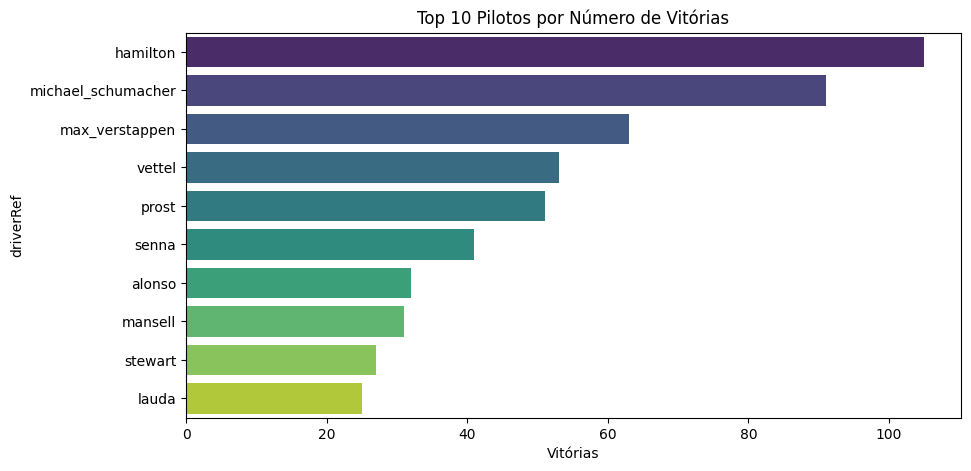

In [22]:
# Top 10 Pilotos com mais vitórias na base de dados
wins = df[df['positionOrder'] == 1].groupby('driverRef')['year'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=wins.values, y=wins.index, palette='viridis')
plt.title('Top 10 Pilotos por Número de Vitórias')
plt.xlabel('Vitórias')
plt.show()

## Pilotos por nacionalidade
Existe um país "formador" de pilotos?

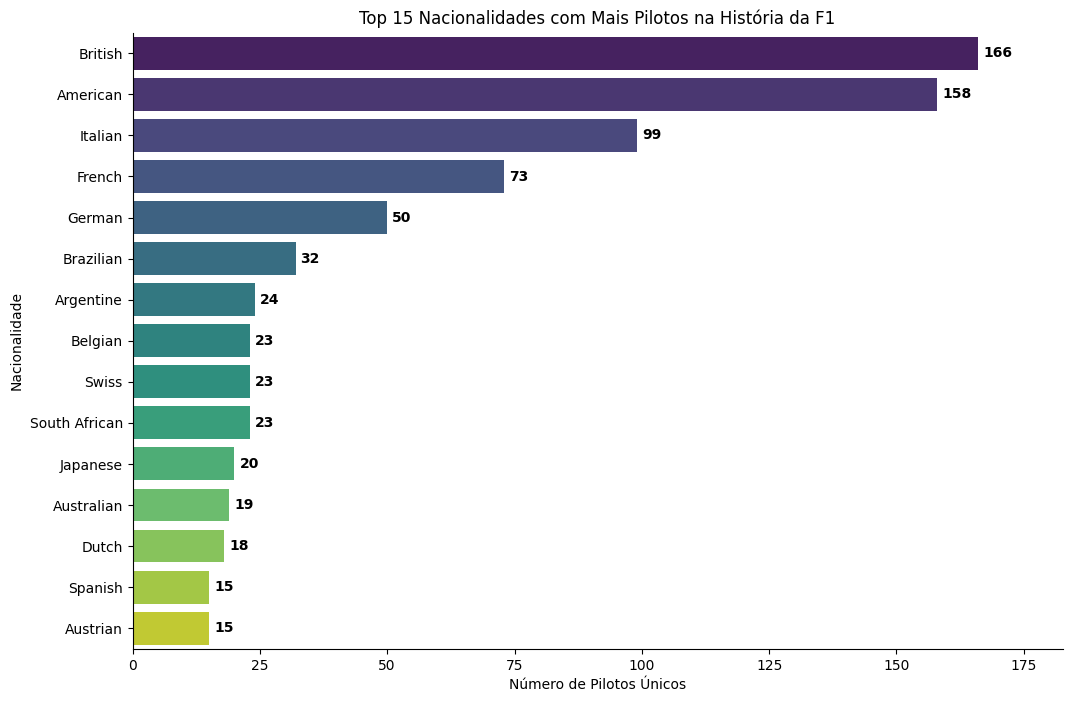

In [72]:
# 1. Isolando pilotos únicos (Usando 'nationality_driver')
unique_drivers = df[['driverId', 'nationality_driver']].drop_duplicates()

# 2. Contagem e filtro dos Top 15
nationality_counts = unique_drivers['nationality_driver'].value_counts().head(15)

plt.figure(figsize=(12, 8))

# 3. Plotagem
ax = sns.barplot(x=nationality_counts.values, y=nationality_counts.index, palette='viridis')

plt.title('Top 15 Nacionalidades com Mais Pilotos na História da F1')
plt.xlabel('Número de Pilotos Únicos')
plt.ylabel('Nacionalidade')

# 4. Rótulos de valor
for i, v in enumerate(nationality_counts.values):
    ax.text(v + 1, i, str(v), color='black', va='center', fontweight='bold')

plt.xlim(0, nationality_counts.max() * 1.1)
sns.despine()
plt.show()

## Equipes com maior número de vitórias

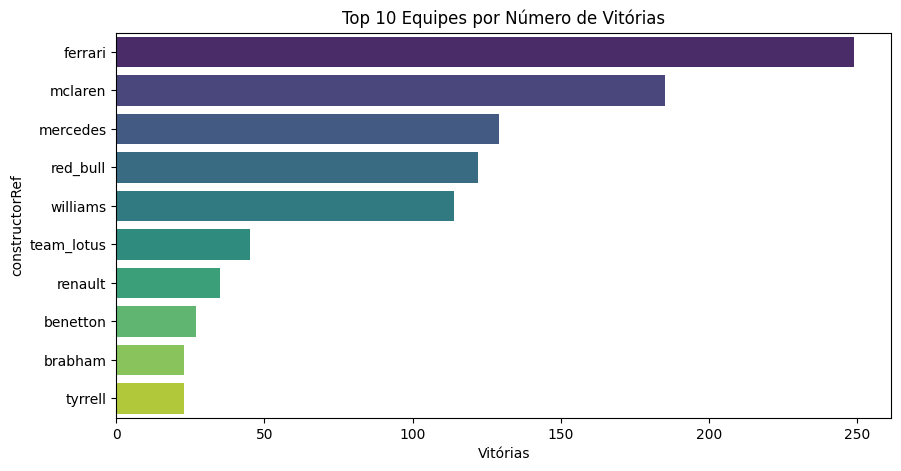

In [28]:
# Top 10 Equipes com mais vitórias na base de dados
wins = df[df['positionOrder'] == 1].groupby('constructorRef')['year'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=wins.values, y=wins.index, palette='viridis')
plt.title('Top 10 Equipes por Número de Vitórias')
plt.xlabel('Vitórias')
plt.show()

## Correlação: Grid vs Posição Final
A posição no grid influencia muito na posição final?

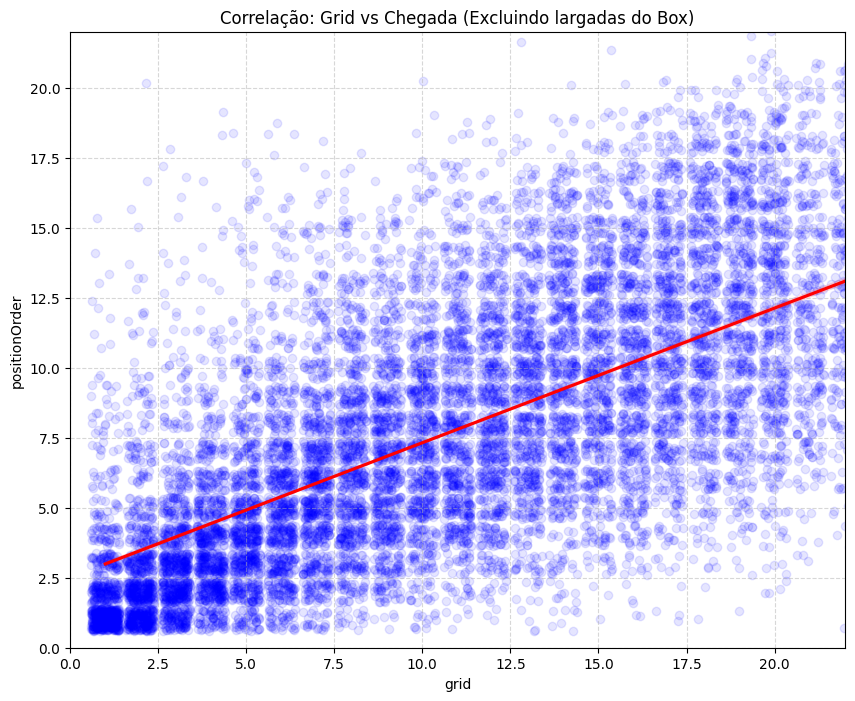

Correlação de Spearman: 0.71


In [29]:
# Filtrar status (Terminou ou +Voltas)
finished_races = df[(df['status'].str.contains('Finished')) | (df['status'].str.contains('\+'))].copy()
finished_races = finished_races[finished_races['grid'] > 0] 

plt.figure(figsize=(10, 8))
sns.regplot(data=finished_races, x='grid', y='positionOrder', 
            x_jitter=0.4, y_jitter=0.4,
            scatter_kws={'alpha': 0.1, 'color': 'blue'}, 
            line_kws={'color': 'red'})

plt.title('Correlação: Grid vs Chegada (Excluindo largadas do Box)')
plt.xlim(0, 22)
plt.ylim(0, 22)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

corr = finished_races[['grid', 'positionOrder']].corr(method='spearman').iloc[0,1]
print(f"Correlação de Spearman: {corr:.2f}")

## Análise de Confiabilidade (Quebras Mecânicas)
Quais equipes sofreram mais falhas mecânicas na história recente (pós-2010)?

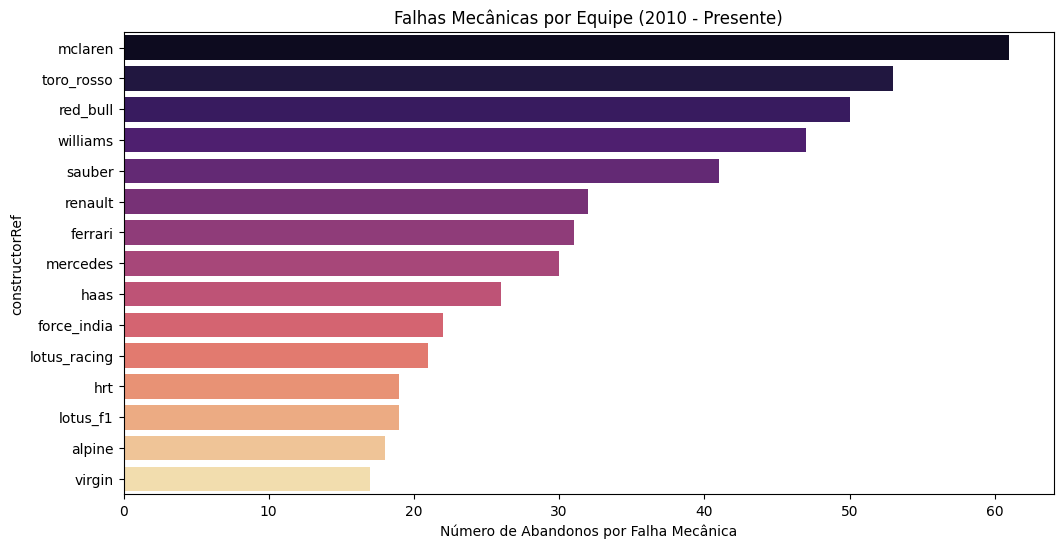

In [24]:
# Definir o que é falha mecânica
mechanical_issues = [
 'Engine',
 'Transmission',
 'Clutch',
 'Electrical',
 'Hydraulics',
 'Gearbox',
 'Radiator',
 'Suspension',
 'Brakes',
 'Overheating',
 'Mechanical',
 'Tyre',
 'Puncture',
 'Driveshaft',
 'Fuel pressure',
 'Water pressure',
 'Throttle',
 'Steering',
 'Technical',
 'Electronics',
 'Exhaust',
 'Oil leak',
 'Wheel rim',
 'Water leak',
 'Fuel pump',
 'Track rod',
 'Oil pressure',
 'Pneumatics',
 'Engine fire',
 'Tyre puncture',
 'Out of fuel',
 'Wheel nut',
 'Handling',
 'Fuel system',
 'Oil line',
 'Launch control',
 'Fuel',
 'Power loss',
 'Drivetrain',
 'Ignition',
 'Chassis',
 'Battery',
 'Stalled',
 'Halfshaft',
 'Crankshaft',
 'Alternator',
 'Differential',
 'Wheel bearing',
 'Vibrations',
 'Oil pump',
 'Fuel leak',
 'Injection',
 'Distributor',
 'Turbo',
 'CV joint',
 'Water pump',
 'Spark plugs',
 'Fuel pipe',
 'Oil pipe',
 'Axle',
 'Water pipe',
 'Magneto',
 'Supercharger',
 'Engine misfire',
 'ERS',
 'Power Unit',
 'Brake duct',
 'Cooling system',
 'Undertray'
]

# Filtro: Últimos anos e apenas top equipes para o gráfico não ficar gigante
recent_df = df[df['year'] >= 2010]
failures = recent_df[recent_df['status'].isin(mechanical_issues)]

# Contagem por equipe
team_failures = failures['constructorRef'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=team_failures.values, y=team_failures.index, palette='magma')
plt.title('Falhas Mecânicas por Equipe (2010 - Presente)')
plt.xlabel('Número de Abandonos por Falha Mecânica')
plt.show()

Evolução das falhas mecânicas ao longo do tempo

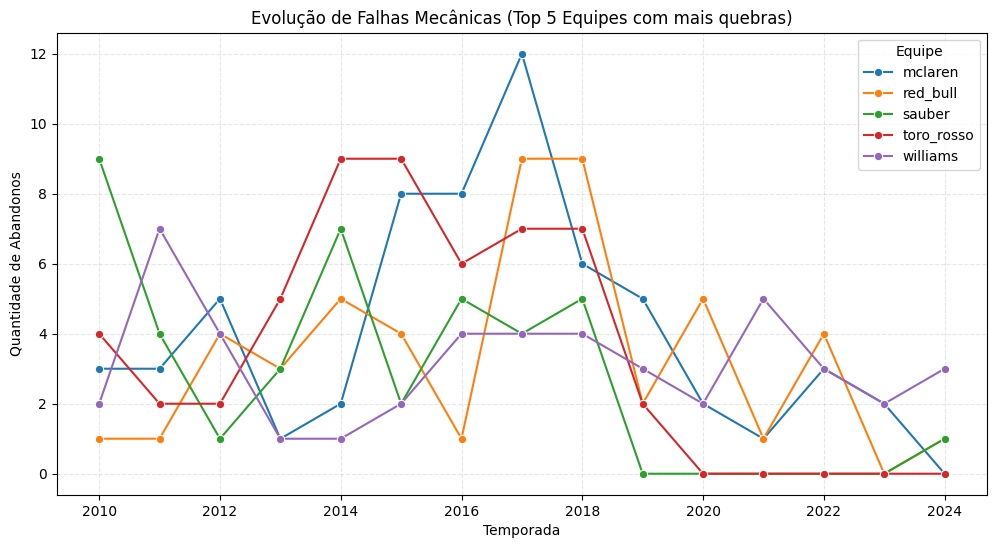

In [51]:
# 5 equipes com mais falhas no total
top_bad_teams = failures['constructorRef'].value_counts().head(5).index

# Filtrar o dataset apenas para essas equipes
failures_filtered = failures[failures['constructorRef'].isin(top_bad_teams)]

evolution = failures_filtered.pivot_table(index='year', columns='constructorRef', aggfunc='size', fill_value=0)

plt.figure(figsize=(12, 6))
sns.lineplot(data=evolution, dashes=False, marker='o')

plt.title('Evolução de Falhas Mecânicas (Top 5 Equipes com mais quebras)')
plt.ylabel('Quantidade de Abandonos')
plt.xlabel('Temporada')
plt.legend(title='Equipe')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

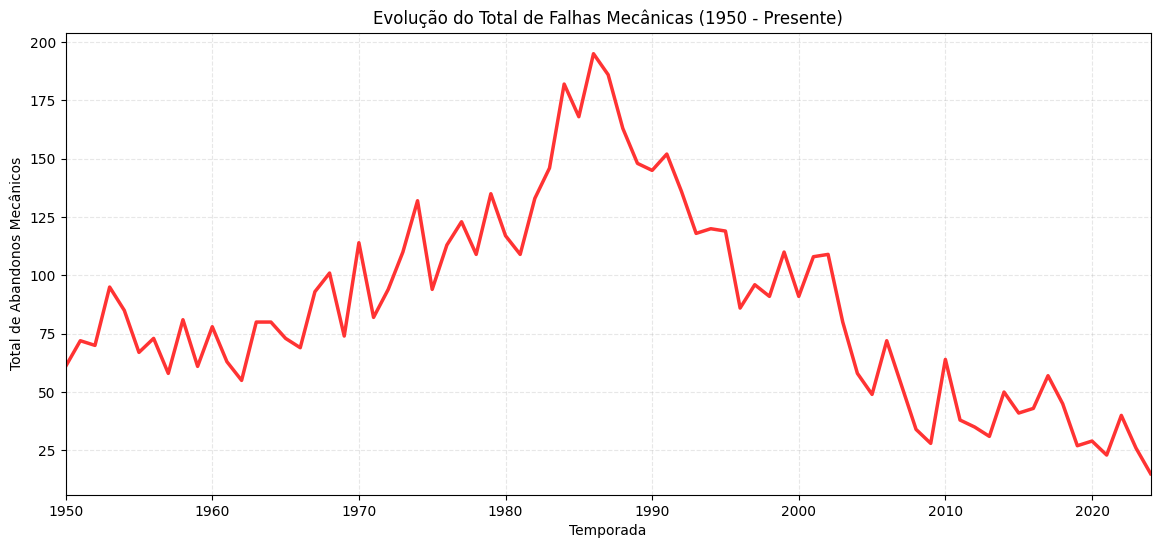

In [32]:
# Contar falhas por ano em todo o histórico
failures_history = df[df['status'].isin(mechanical_issues)].groupby('year').size()

plt.figure(figsize=(14, 6))

sns.lineplot(x=failures_history.index, y=failures_history.values, 
             color='#FF3333', linewidth=2.5)

plt.title('Evolução do Total de Falhas Mecânicas (1950 - Presente)')
plt.ylabel('Total de Abandonos Mecânicos')
plt.xlabel('Temporada')

plt.grid(True, linestyle='--', alpha=0.3)
plt.xlim(failures_history.index.min(), failures_history.index.max())
plt.show()

## Idade vs Performance
Existe uma "idade de ouro" para pilotos de F1?

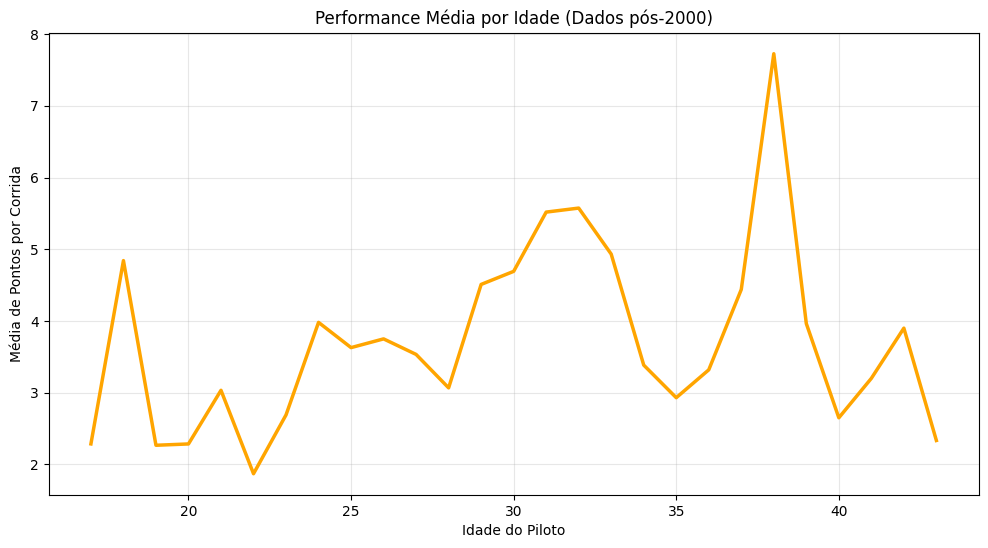

In [66]:
# Converter para datetime
df['dob'] = pd.to_datetime(df['dob'])
df['date'] = pd.to_datetime(df['date'])

# Calcular idade em anos
df['driver_age'] = (df['date'] - df['dob']).dt.days / 365.25

# Filtrar era moderna (pontuação mudou muito, vamos focar em posições médias ou normalizar)
# Para simplificar, vamos ver a média de pontos por idade (considerando viés que só os bons ficam velhos na F1)
age_performance = df[df['year'] >= 2000].groupby(df['driver_age'].astype(int))['points'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=age_performance.index, y=age_performance.values, color='orange', linewidth=2.5)
plt.title('Performance Média por Idade (Dados pós-2000)')
plt.xlabel('Idade do Piloto')
plt.ylabel('Média de Pontos por Corrida')
plt.grid(True, alpha=0.3)
plt.show()

## Distribuição de Tempos de Pit Stop
Qual equipe é mais rápida e consistente nos boxes?

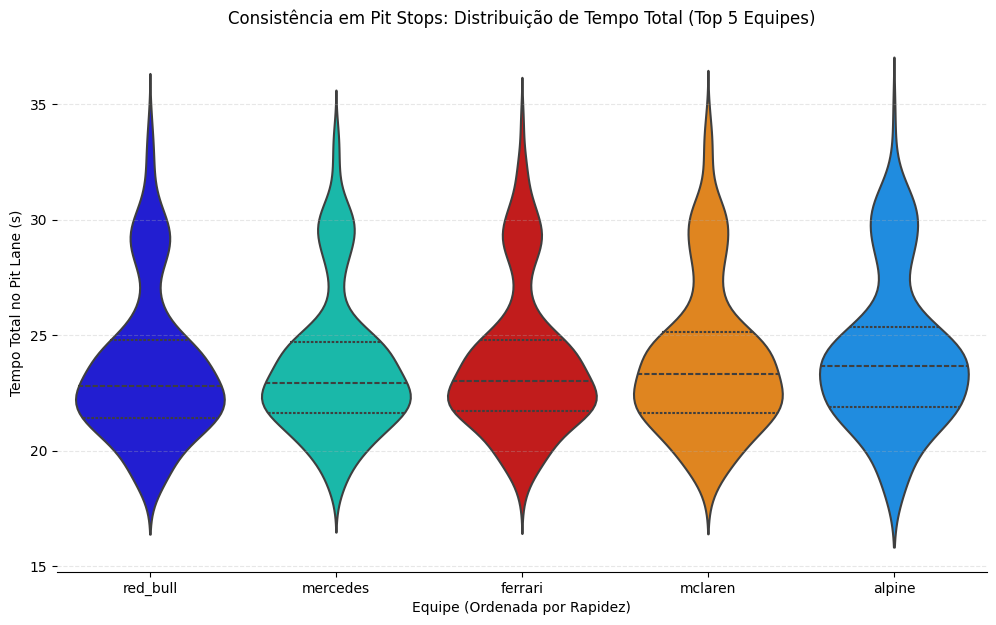

In [ ]:
team_colors = {
    'red_bull': '#0600EF',  # Azul Escuro
    'mercedes': '#00D2BE',  # Turquesa/Prata
    'ferrari': '#DC0000',   # Vermelho
    'mclaren': '#FF8700',   # Laranja Papaya
    'alpine': '#0090FF'     # Azul Alpine
}

# Ordenar o dataframe pela mediana do tempo (da mais rápida para mais lenta)
order = clean_pits.groupby('constructorRef')['seconds'].median().sort_values().index

plt.figure(figsize=(12, 7))

# Violin Plot
sns.violinplot(data=clean_pits, x='constructorRef', y='seconds', 
               order=order, palette=team_colors, 
               inner='quartile', linewidth=1.5)

plt.title('Consistência em Pit Stops: Distribuição de Tempo Total (Top 5 Equipes)')
plt.xlabel('Equipe (Ordenada por Rapidez)')
plt.ylabel('Tempo Total no Pit Lane (s)')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True)

plt.show()

Com o passar do tempo as equipes melhoraram os tempos de pitstops?

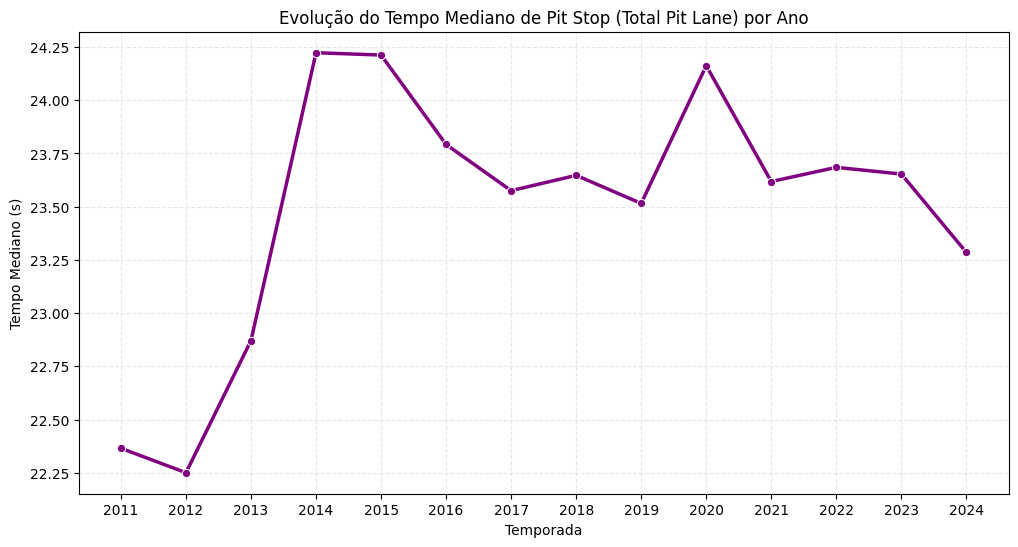

In [63]:
# Merge para associar os Pit Stops aos Anos
races_years = df[['raceId', 'year']].drop_duplicates()
pits_evolution = df_pitstops.merge(races_years, on='raceId', how='inner')

# Converter para segundos e filtrar anomalias
# Mantendo apenas paradas < 50s para focar em pit stops de corrida (pneus/asa) e excluir longos reparos mecânicos ou recolhimento do carro.
pits_evolution['seconds'] = pits_evolution['milliseconds'] / 1000
pits_clean = pits_evolution[pits_evolution['seconds'] < 50]

# Calcular a Mediana por ano (mais robusto que média)
yearly_stats = pits_clean.groupby('year')['seconds'].median().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_stats, x='year', y='seconds', 
             marker='o', color='purple', linewidth=2.5)

plt.title('Evolução do Tempo Mediano de Pit Stop (Total Pit Lane) por Ano')
plt.xlabel('Temporada')
plt.ylabel('Tempo Mediano (s)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.xticks(yearly_stats['year'].unique()) 
plt.show()

## Fator Ultrapassagem
Quais pistas são mais difíceis de escalar o pelotão?

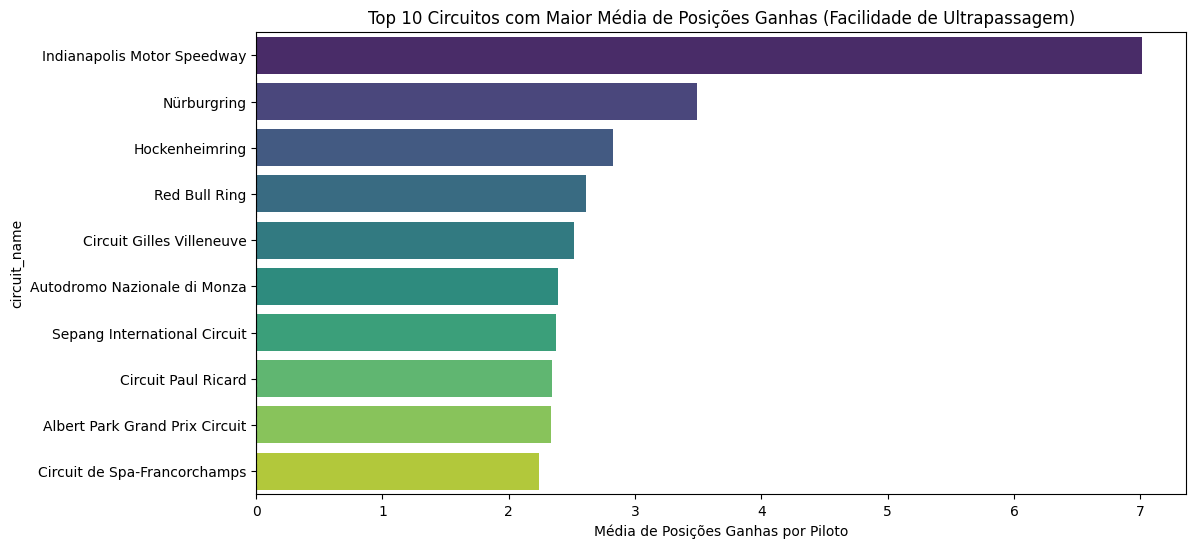

In [65]:
# Filtrar apenas quem terminou a corrida para medir performance real, não quebras
finishers = df[df['status'].str.contains('Finished')].copy()

# Calcular Delta: Positivo = Ganhou posições, Negativo = Perdeu posições
finishers['positions_gained'] = finishers['grid'] - finishers['positionOrder']

# Agrupar por circuito (apenas circuitos com muitas corridas para significância estatística)
circuit_stats = finishers.groupby('circuit_name')['positions_gained'].agg(['mean', 'count'])
circuit_stats = circuit_stats[circuit_stats['count'] > 100] # Pelo menos ~5 corridas na história

# Top 10 Pistas com mais ganhos de posição
top_overtake_tracks = circuit_stats.sort_values(by='mean', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_overtake_tracks['mean'], y=top_overtake_tracks.index, palette='viridis')
plt.title('Top 10 Circuitos com Maior Média de Posições Ganhas (Facilidade de Ultrapassagem)')
plt.xlabel('Média de Posições Ganhas por Piloto')
plt.axvline(0, color='black', linestyle='--')
plt.show()

## Conversão de Pole Position
O quão decisivo é o sábado? (Qualificação)

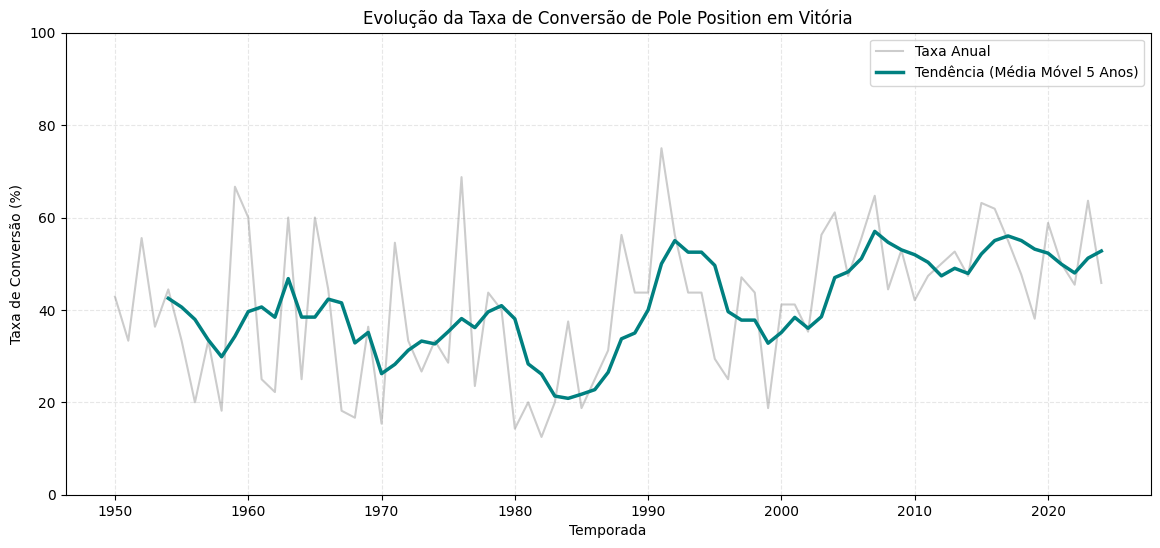

In [ ]:
# Filtrar Poles e converter para binário
poles = df[df['grid'] == 1].copy()
poles['converted_win'] = (poles['positionOrder'] == 1).astype(int)

# Agrupar por ANO
conversion_yearly = poles.groupby('year')['converted_win'].mean() * 100

plt.figure(figsize=(14, 6))

# Linha dos dados brutos
sns.lineplot(x=conversion_yearly.index, y=conversion_yearly.values, 
             color='gray', alpha=0.4, label='Taxa Anual')

# Linha de Tendência (Média Móvel de 5 anos)
sns.lineplot(x=conversion_yearly.index, y=conversion_yearly.rolling(window=5).mean(), 
             color='teal', linewidth=2.5, label='Tendência (Média Móvel 5 Anos)')

plt.title('Evolução da Taxa de Conversão de Pole Position em Vitória')
plt.ylabel('Taxa de Conversão (%)')
plt.xlabel('Temporada')
plt.ylim(0, 100)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

# Clustering

## Clusterização de Pilotos

In [102]:
# ==========================================
# 1. FEATURE ENGINEERING (ATUALIZADO)
# ==========================================

# --- Conversão de Datas e Cálculo de Idade ---
# Garantir que as colunas de data estejam no formato datetime
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Calcular a idade exata em cada corrida (em anos)
df['driver_age'] = (df['date'] - df['dob']).dt.days / 365.25

# --- Features Anteriores ---
df['is_win'] = (df['positionOrder'] == 1).astype(int)
df['is_podium'] = (df['positionOrder'] <= 3).astype(int)
finished_mask = df['status'].str.contains('Finished') | df['status'].str.contains('\+')
df['is_dnf'] = (~finished_mask).astype(int)
driver_errors = ['Collision', 'Accident', 'Spun off', 'Collision damage']
df['is_crash'] = df['status'].str.contains('|'.join(driver_errors), case=False, regex=True).astype(int)
df['positions_gained'] = np.where(finished_mask, df['grid'] - df['positionOrder'], np.nan)
team_race_points = df.groupby(['year', 'raceId', 'constructorId'])['points'].transform('sum')
df['team_point_share'] = df['points'] / team_race_points
df['team_point_share'] = df['team_point_share'].fillna(0)

# --- Features de Tempo/Ritmo ---
df['fastest_lap_rank'] = pd.to_numeric(df['rank'], errors='coerce')
df['qualy_race_diff'] = df['grid'] - df['fastest_lap_rank']

# ==========================================
# 2. AGREGAÇÃO POR PILOTO
# ==========================================

driver_stats = df.groupby('driverRef').filter(lambda x: len(x) > 20)

data = driver_stats.groupby('driverRef').agg({
    # Features de Performance
    'grid': 'mean',
    'positionOrder': 'mean',
    'points': 'mean',
    'is_win': 'mean',       
    'is_podium': 'mean',
    'is_dnf': 'mean',
    'is_crash': 'mean',
    'positions_gained': 'mean',
    'team_point_share': 'mean',
    'fastest_lap_rank': 'mean',
    'qualy_race_diff': 'mean',
    
    # NOVAS FEATURES (Longevidade e Idade)
    'raceId': 'count',           # Número total de corridas
    'year': 'nunique',           # Número de temporadas distintas (anos únicos)
    'driver_age': 'mean'         # Idade média durante a carreira
}).rename(columns={
    'raceId': 'total_races',     # <--- Número de Corridas
    'year': 'total_seasons',     # <--- Número de Temporadas
    'driver_age': 'avg_age',     # <--- Idade Média
    'is_win': 'win_rate',       
    'is_podium': 'podium_rate', 
    'is_dnf': 'dnf_rate',
    'is_crash': 'crash_rate',
    'fastest_lap_rank': 'avg_fastest_lap_rank'
})

data = data.fillna(0)

# ==========================================
# 3. ESCALONAMENTO
# ==========================================

# Adicionando as novas features na lista do Scaler
features_list = [
    'grid', 'positionOrder', 'points', 
    'podium_rate', 'dnf_rate', 'crash_rate', 
    'positions_gained', 'team_point_share',
    'avg_fastest_lap_rank', 'qualy_race_diff',
    'total_races', 'total_seasons', 'avg_age' # <--- Adicionadas aqui
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[features_list])

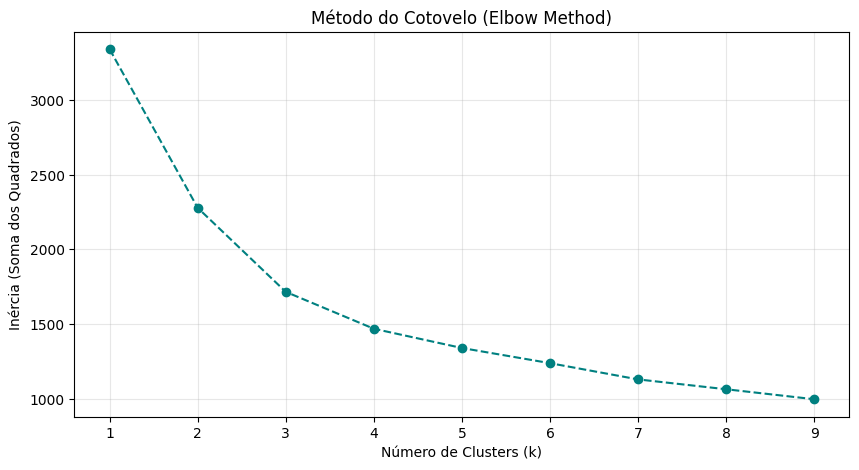

In [103]:
# Curva de Inércia (ELBOW METHOD)
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='teal')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (Soma dos Quadrados)')
plt.grid(True, alpha=0.3)
plt.show()

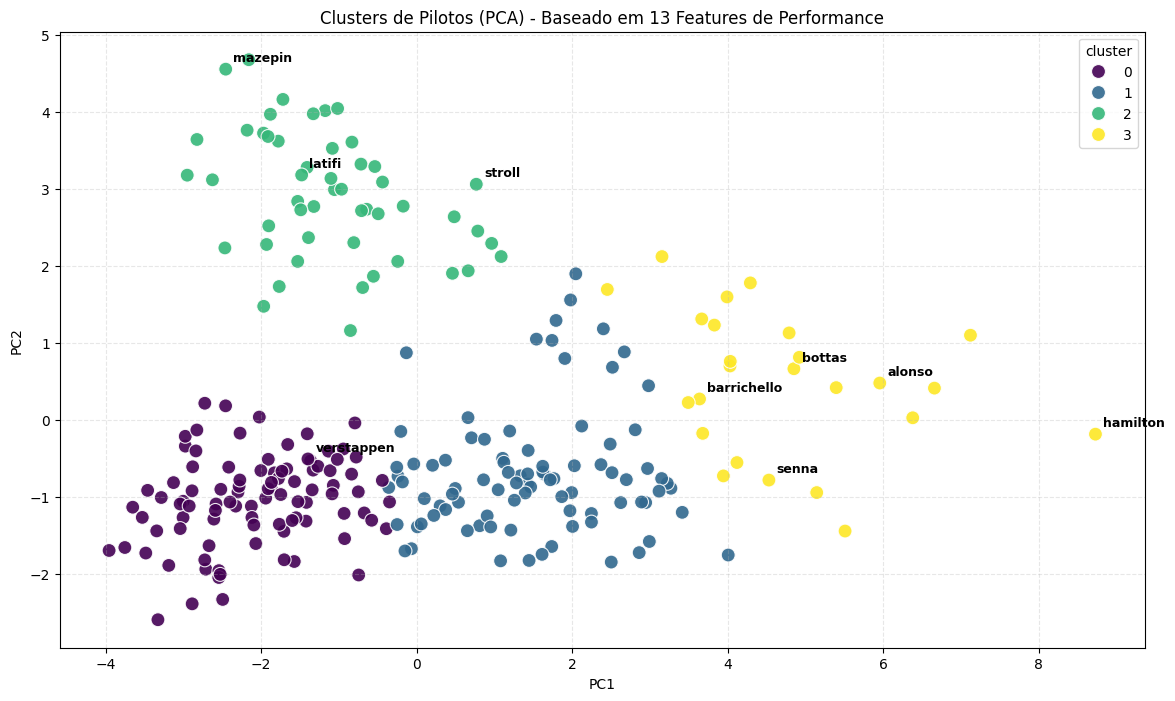


Perfil Médio de cada Cluster (Valores Originais):


,grid,positionOrder,points,podium_rate,dnf_rate,crash_rate,positions_gained,team_point_share,avg_fastest_lap_rank,qualy_race_diff,total_races,total_seasons,avg_age
cluster,,,,,,,,,,,,,
0,14.42,17.10,0.16,0.01,0.66,0.13,8.01,0.06,0.00,0.00,54.84,5.09,28.89
1,9.32,10.99,1.50,0.17,0.45,0.10,3.15,0.25,1.61,-0.04,111.60,9.78,31.70
2,15.73,14.74,0.51,0.01,0.28,0.12,2.67,0.10,13.94,1.64,61.54,3.86,25.60
3,6.85,8.19,6.08,0.31,0.21,0.07,1.00,0.43,6.38,-0.02,221.84,12.56,28.91


In [105]:
# Clusterização
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(X_scaled)

# Visualização com PCA (Redução de Dimensionalidade)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
data['pca_1'] = X_pca[:, 0]
data['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(14, 8))
sns.scatterplot(data=data, x='pca_1', y='pca_2', hue='cluster', palette='viridis', s=100, alpha=0.9)

# Anotar alguns nomes famosos para interpretar o gráfico
notable_drivers = ['hamilton', 'schumacher', 'senna', 'verstappen', 'alonso', 
                   'latifi', 'mazepin', 'stroll', 'bottas', 'barrichello']

for driver in notable_drivers:
    if driver in data.index:
        plt.text(data.loc[driver, 'pca_1']+0.1, 
                 data.loc[driver, 'pca_2']+0.1, 
                 driver, fontsize=9, fontweight='bold', color='black')

plt.title(f'Clusters de Pilotos (PCA) - Baseado em {len(features_list)} Features de Performance')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Interpretação Estatística dos Clusters
print("\nPerfil Médio de cada Cluster (Valores Originais):")
data.groupby('cluster')[features_list].mean().round(2)